In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller  # <--- Corrected import
import warnings

warnings.filterwarnings('ignore')

# Load the features dataset
df = pd.read_csv('../data/processed/ae_features.csv', parse_dates=['WeekEndingDate'])

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Boards: {df['BoardName'].nunique()}")
print(f"Date range: {df['WeekEndingDate'].min()} → {df['WeekEndingDate'].max()}")

print("\nModelling features available:")
feature_cols = [c for c in df.columns if c not in 
                 ['WeekEndingDate','HBT','BoardName','Country',
                 'Attendances','Within4Hours','Over4Hours',
                 'Over8Hours','Over12Hours','Within4HoursPct']]

for f in feature_cols:
    print(f"  {f}")

Rows: 6446
Columns: 43
Boards: 11
Date range: 2015-02-22 00:00:00 → 2026-05-10 00:00:00

Modelling features available:
  BreachRate
  BreachedTarget
  WeekOfYear
  Month
  Year
  FluSeasonFlag
  WinterFlag
  ChristmasWeek
  CovidPhase
  CovidEra
  PostCovidStress
  VaxRollout
  Lag1_BreachRate
  Lag2_BreachRate
  Lag4_BreachRate
  Lag8_BreachRate
  Lag1_Attendances
  Lag4_Attendances
  RollingMean4W
  RollingMean8W
  RollingStd4W
  RollingMax4W
  BreachRateDelta
  SIMDScore
  IsUrban
  PopulationK
  AttendancesPer1000
  FluSearchIndex
  IsSchoolHoliday
  DaysToNextHoliday
  DaysSinceHoliday
  TotalClinicalWTE
  StaffingRatioPer1000
  StaffingPressureFlag


In [2]:
from statsmodels.tsa.stattools import adfuller

# Isolate Forth Valley
fv = df[df['BoardName'] == 'Forth Valley'].sort_values('WeekEndingDate').copy()
print(f"Forth Valley weeks: {len(fv)}")

def adf_report(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    p = result[1]
    stationary = "✅ Stationary" if p < 0.05 else "❌ Non-stationary"
    print(f"{name:30}  ADF stat: {result[0]:7.3f}  p-value: {p:.4f}  {stationary}")

print("\n--- ADF Tests on Forth Valley ---")
adf_report(fv['BreachRate'],          'BreachRate (raw)')
adf_report(fv['BreachRate'].diff(),   'BreachRate (1st diff)')
adf_report(fv['Attendances'],         'Attendances (raw)')
adf_report(fv['Attendances'].diff(),  'Attendances (1st diff)')

Forth Valley weeks: 586

--- ADF Tests on Forth Valley ---
BreachRate (raw)                ADF stat:  -1.296  p-value: 0.6311  ❌ Non-stationary
BreachRate (1st diff)           ADF stat: -18.772  p-value: 0.0000  ✅ Stationary
Attendances (raw)               ADF stat:  -3.968  p-value: 0.0016  ✅ Stationary
Attendances (1st diff)          ADF stat: -22.937  p-value: 0.0000  ✅ Stationary


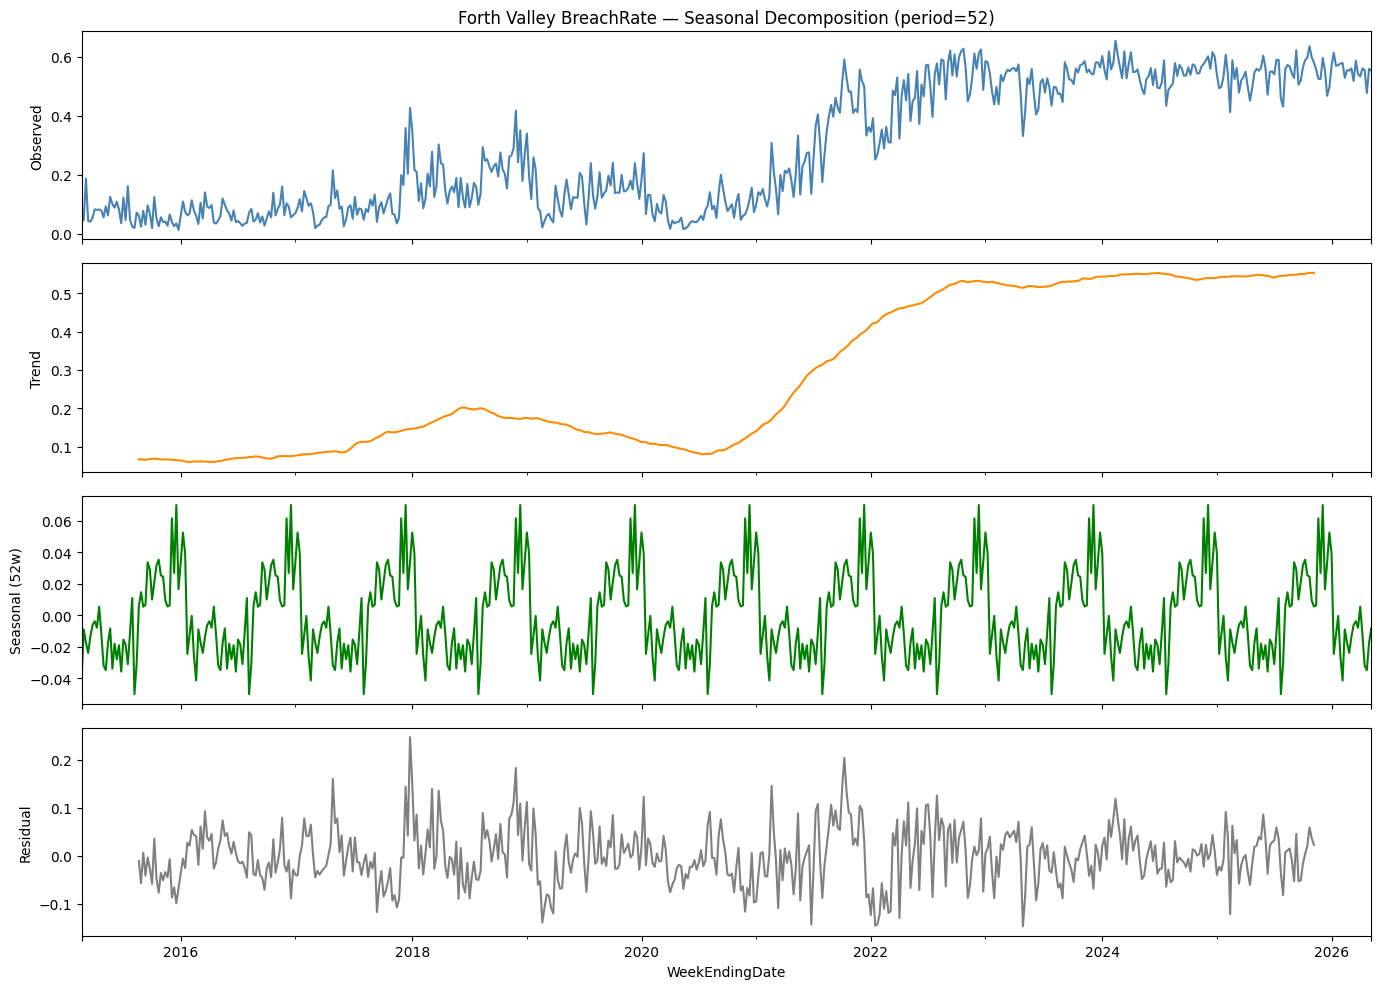

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

fv_series = fv.set_index('WeekEndingDate')['BreachRate'].dropna()

decomp = seasonal_decompose(fv_series, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color='steelblue');  axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1], color='darkorange');    axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='green');      axes[2].set_ylabel('Seasonal (52w)')
decomp.resid.plot(ax=axes[3], color='grey');          axes[3].set_ylabel('Residual')

axes[0].set_title('Forth Valley BreachRate — Seasonal Decomposition (period=52)')
plt.tight_layout()
plt.savefig('../data/processed/fv_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train on everything up to end of 2022, test on 2023 onwards
train = fv[fv['WeekEndingDate'] < '2023-01-01'].set_index('WeekEndingDate')
test  = fv[fv['WeekEndingDate'] >= '2023-01-01'].set_index('WeekEndingDate')

print(f"Train weeks: {len(train)}  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test weeks:  {len(test)}   ({test.index.min().date()} → {test.index.max().date()})")

# Fit SARIMAX — seasonal order s=52 captures the annual cycle
# Start simple: (1,1,1)(1,1,0,52) — we'll tune later
model_baseline = SARIMAX(
    train['BreachRate'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("\nFitting baseline SARIMAX(1,1,1)(1,1,0,52)... (may take 1–2 minutes)")
result_baseline = model_baseline.fit(disp=False)
print(result_baseline.summary())

Train weeks: 410  (2015-02-22 → 2022-12-25)
Test weeks:  176   (2023-01-01 → 2026-05-10)

Fitting baseline SARIMAX(1,1,1)(1,1,0,52)... (may take 1–2 minutes)
                                      SARIMAX Results                                      
Dep. Variable:                          BreachRate   No. Observations:                  410
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood                 352.308
Date:                             Fri, 22 May 2026   AIC                           -696.616
Time:                                     17:48:50   BIC                           -681.748
Sample:                                 02-22-2015   HQIC                          -690.668
                                      - 12-25-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

=== Baseline SARIMAX (no exogenous features) ===
  MAPE : 71.77%
  RMSE : 0.4319
  MAE  : 0.3836


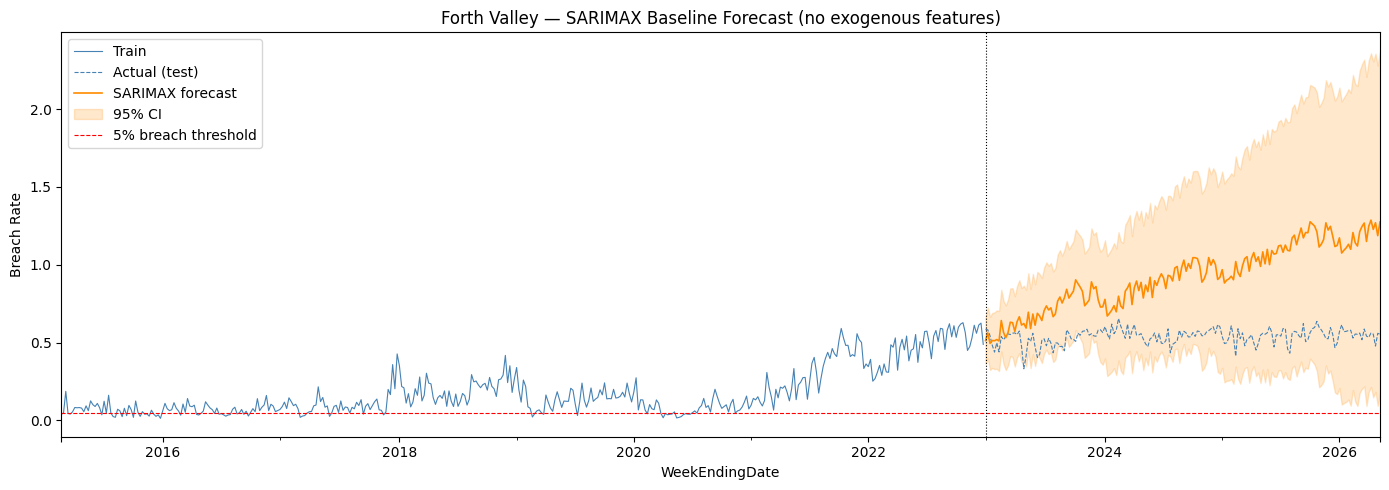

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Forecast over the test period
forecast_baseline = result_baseline.get_forecast(steps=len(test))
pred              = forecast_baseline.predicted_mean
conf_int          = forecast_baseline.conf_int()

# Metrics
actual = test['BreachRate'].values
mape   = np.mean(np.abs((actual - pred.values) / np.clip(actual, 0.01, None))) * 100
rmse   = np.sqrt(mean_squared_error(actual, pred.values))
mae    = mean_absolute_error(actual, pred.values)

print("=== Baseline SARIMAX (no exogenous features) ===")
print(f"  MAPE : {mape:.2f}%")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
train['BreachRate'].plot(ax=ax, color='steelblue', linewidth=0.8, label='Train')
test['BreachRate'].plot(ax=ax, color='steelblue', linewidth=0.8, linestyle='--', label='Actual (test)')
pred.plot(ax=ax, color='darkorange', linewidth=1.2, label='SARIMAX forecast')
ax.fill_between(conf_int.index,
                conf_int.iloc[:, 0],
                conf_int.iloc[:, 1],
                alpha=0.2, color='darkorange', label='95% CI')
ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='5% breach threshold')
ax.axvline(pd.Timestamp('2023-01-01'), color='black', linestyle=':', linewidth=0.8)
ax.set_title('Forth Valley — SARIMAX Baseline Forecast (no exogenous features)')
ax.set_ylabel('Breach Rate')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../data/processed/fv_sarimax_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Define exogenous features for SARIMAX
# These must be available at forecast time (no data leakage)
exog_cols = [
    'CovidEra',
    'PostCovidStress',
    'FluSeasonFlag',
    'WinterFlag',
    'ChristmasWeek',
    'IsSchoolHoliday',
    'StaffingPressureFlag',
    'FluSearchIndex',
]

# Verify no NaNs in exog columns for train/test
print("NaN check on exogenous features:")
for col in exog_cols:
    nans = fv[col].isna().sum()
    print(f"  {col:30} NaNs: {nans}")

train_exog = train[exog_cols]
test_exog  = test[exog_cols]

print(f"\nTrain exog shape: {train_exog.shape}")
print(f"Test exog shape:  {test_exog.shape}")

NaN check on exogenous features:
  CovidEra                       NaNs: 0
  PostCovidStress                NaNs: 0
  FluSeasonFlag                  NaNs: 0
  WinterFlag                     NaNs: 0
  ChristmasWeek                  NaNs: 0
  IsSchoolHoliday                NaNs: 0
  StaffingPressureFlag           NaNs: 0
  FluSearchIndex                 NaNs: 1

Train exog shape: (410, 8)
Test exog shape:  (176, 8)


In [7]:
model_exog = SARIMAX(
    train['BreachRate'],
    exog=train_exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Fitting SARIMAX with exogenous features... (2–3 minutes)")
result_exog = model_exog.fit(disp=False)
print(result_exog.summary())

Fitting SARIMAX with exogenous features... (2–3 minutes)
                                      SARIMAX Results                                      
Dep. Variable:                          BreachRate   No. Observations:                  410
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood                 359.373
Date:                             Fri, 22 May 2026   AIC                           -694.746
Time:                                     18:02:07   BIC                           -650.142
Sample:                                 02-22-2015   HQIC                          -676.904
                                      - 12-25-2022                                         
Covariance Type:                               opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
CovidEra                -0.10

In [8]:
forecast_exog = result_exog.get_forecast(steps=len(test), exog=test_exog)
pred_exog     = forecast_exog.predicted_mean
conf_exog     = forecast_exog.conf_int()

actual = test['BreachRate'].values

def metrics(actual, predicted, label):
    predicted = np.array(predicted)
    mape = np.mean(np.abs((actual - predicted) / np.clip(actual, 0.01, None))) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    print(f"\n=== {label} ===")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    return mape, rmse, mae

mape_b, rmse_b, mae_b = metrics(actual, pred.values,      "Baseline SARIMAX (no exog)")
mape_e, rmse_e, mae_e = metrics(actual, pred_exog.values, "SARIMAX + exogenous features")

print(f"\n--- Improvement ---")
print(f"  MAPE improvement: {mape_b - mape_e:.2f} percentage points")
print(f"  RMSE improvement: {rmse_b - rmse_e:.4f}")

MissingDataError: exog contains inf or nans